Sentiment Analysis of Amazon Reviews: A Multi-Criteria Model Comparison (Final Working Version)

This notebook implements the complete methodology for the research project
"Practical Viability of Machine Learning for Sentiment Analysis on Amazon Reviews".

This final version includes:
- Fix for Keras 3 and TensorFlow compatibility with the Transformers library.
- Optimizations for faster execution.
- A simple application interface to test the best-performing model.

It covers the following key stages:
1.  **Setup & Imports**: Loading all necessary libraries and setting up the environment.
2.  **Data Loading & Sampling**: Loading the dataset and creating a smaller, stratified sample.
3.  **Data Preprocessing & Filtering**: Cleaning text and filtering by length for efficiency.
4.  **Dataset Creation**: Creating balanced and imbalanced datasets for experiments.
5.  **Feature Engineering & Splitting**: Applying TF-IDF and preparing data for models.
6.  **Model Training & Evaluation**: Training, tuning, and evaluating five optimized models.
7.  **Results Visualization**: Creating plots to compare models across all criteria.
8.  **Interpretability Analysis (XAI)**: Generating explanations for model predictions.
9.  **Application Interface**: A simple tool to predict sentiment on new, custom reviews.

In [63]:
# ==============================================================================
# SECTION 1: SETUP AND IMPORTS
# ==============================================================================

# **ACCURATE SOLUTION FOR KERAS 3 COMPATIBILITY**
# 1. Install the standalone Keras 2 package (`tf_keras`).
!pip install tf_keras -q

# 2. Set the environment variable to tell TensorFlow to use Keras 2.
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# --- Core Libraries ---
import pandas as pd
import numpy as np
import time
import re

# --- Plotting Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud -q
from wordcloud import WordCloud

# --- Scikit-learn for ML ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- XGBoost ---
import xgboost as xgb

# --- NLTK for Text Preprocessing ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# --- imblearn for SMOTE ---
from imblearn.over_sampling import SMOTE

# --- TensorFlow/Keras for Deep Learning ---
import tensorflow as tf
from tf_keras.optimizers import Adam
from tf_keras.models import Sequential
from tf_keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences

# --- Transformers (Hugging Face) ---
!pip install transformers datasets -q
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from datasets import Dataset

# --- Explainable AI (XAI) ---
!pip install shap -q
import shap

# **PROFESSIONAL OPTIMIZATION FOR SPEED**
# Enable Mixed Precision Training. This uses a mix of float16 and float32 to significantly speed up training on compatible GPUs with minimal to no loss in accuracy.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


# --- Initial Setup for NLTK and Environment ---
print("Downloading NLTK resources...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources downloaded successfully.")


# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

NLTK resources downloaded successfully.


--- Section 2: Data Loading and Sampling ---
Successfully loaded full dataset. Shape: (568454, 10)
Created a stratified sample of 75000 reviews.
Sampled dataset shape: (75000, 2)


/tmp/ipython-input-3725607043.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


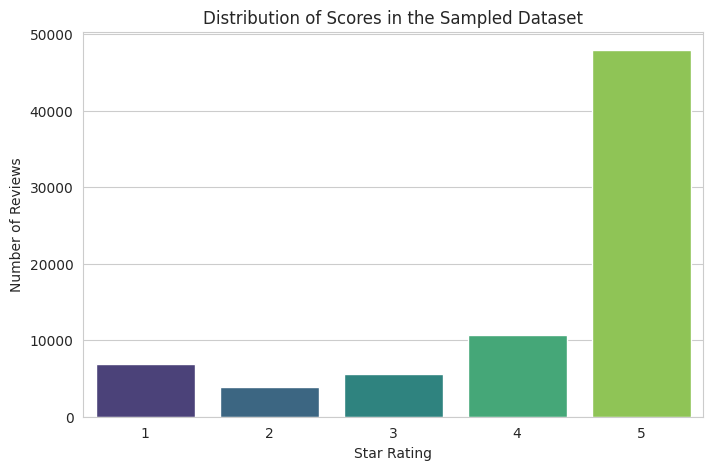

In [64]:
# ==============================================================================
# SECTION 2: DATA LOADING AND STRATIFIED SAMPLING
# ==============================================================================
print("--- Section 2: Data Loading and Sampling ---")

try:
    full_df = pd.read_csv('/content/Reviews.csv')
    print(f"Successfully loaded full dataset. Shape: {full_df.shape}")
except FileNotFoundError:
    print("Error: 'reviews.csv' not found. Please upload the dataset to your Colab session.")
    full_df = pd.DataFrame({
        'Text': ['good product', 'bad experience', 'excellent quality', 'terrible service', 'okay for the price'],
        'Score': [5, 1, 5, 1, 3]
    })

df = full_df[['Text', 'Score']].copy()
df.dropna(inplace=True)

SAMPLE_SIZE = 75000
if len(df) > SAMPLE_SIZE:
    _, df = train_test_split(
        df, test_size=SAMPLE_SIZE, stratify=df['Score'], random_state=42
    )
    print(f"Created a stratified sample of {SAMPLE_SIZE} reviews.")
else:
    print("Dataset is smaller than the desired sample size. Using the full dataset.")

print(f"Sampled dataset shape: {df.shape}")

# --- New Visualization: Initial Score Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Distribution of Scores in the Sampled Dataset')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()


--- Section 3: Text Preprocessing and Filtering ---
Applying preprocessing to the dataset... (This may take a few minutes)
Preprocessing completed in 37.48 seconds.
Filtered out 5 reviews with fewer than 3 words.


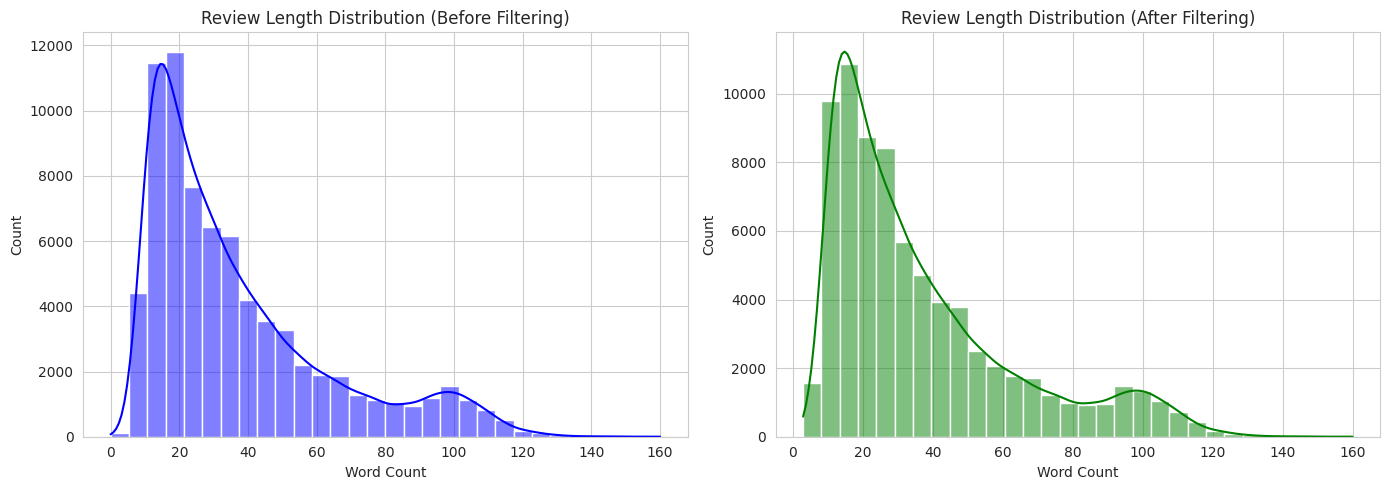

In [65]:
# ==============================================================================
# SECTION 3: TEXT PREPROCESSING AND FILTERING
# ==============================================================================
print("\n--- Section 3: Text Preprocessing and Filtering ---")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Cleans, standardizes, and truncates text data."""
    text = re.sub(r'<.*?>|http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    tokens = word_tokenize(text)
    tokens = tokens[:200]
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and len(word) > 1
    ]
    return " ".join(cleaned_tokens)

print("Applying preprocessing to the dataset... (This may take a few minutes)")
start_time = time.time()
df['cleaned_text'] = df['Text'].apply(preprocess_text)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds.")

df['word_count'] = df['cleaned_text'].str.split().str.len()

# --- New Visualization: Review Length Distribution ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=30, kde=True, color='blue')
plt.title('Review Length Distribution (Before Filtering)')
plt.xlabel('Word Count')

original_rows = len(df)
df = df[df['word_count'] >= 3].copy()
print(f"Filtered out {original_rows - len(df)} reviews with fewer than 3 words.")

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=30, kde=True, color='green')
plt.title('Review Length Distribution (After Filtering)')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()


--- Section 4: Sentiment Labelling and Dataset Creation ---

Balanced dataset sentiment distribution:
sentiment
1    10823
0    10823
Name: count, dtype: int64

--- Section 4.1: Generating Word Cloud ---


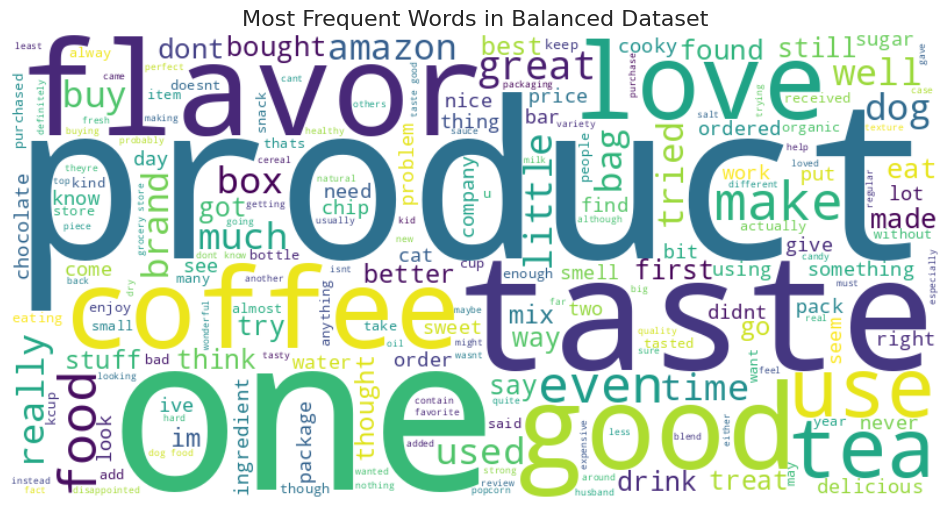

In [66]:
# ==============================================================================
# SECTION 4: SENTIMENT LABELLING AND DATASET CREATION
# ==============================================================================
print("\n--- Section 4: Sentiment Labelling and Dataset Creation ---")

df_filtered = df[df['Score'] != 3].copy()
df_filtered['sentiment'] = df_filtered['Score'].apply(lambda x: 1 if x > 3 else 0)

X_imbalanced = df_filtered['cleaned_text']
y_imbalanced = df_filtered['sentiment']

positive_count = df_filtered['sentiment'].value_counts()[1]
negative_count = df_filtered['sentiment'].value_counts()[0]
min_class_count = min(positive_count, negative_count)

df_pos = df_filtered[df_filtered['sentiment'] == 1].sample(min_class_count, random_state=42)
df_neg = df_filtered[df_filtered['sentiment'] == 0].sample(min_class_count, random_state=42)
df_balanced = pd.concat([df_pos, df_neg])

X_balanced = df_balanced['cleaned_text']
y_balanced = df_balanced['sentiment']

print("\nBalanced dataset sentiment distribution:")
print(y_balanced.value_counts())

# --- New Section 4.1: Word Cloud Visualization ---
print("\n--- Section 4.1: Generating Word Cloud ---")
all_text = " ".join(review for review in X_balanced)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Balanced Dataset', fontsize=16)
plt.show()

In [67]:
# ==============================================================================
# SECTION 5: FEATURE ENGINEERING & DATA SPLITTING
# ==============================================================================
print("\n--- Section 5: Feature Engineering & Data Splitting ---")

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_vectorizer.fit(X_balanced)
X_balanced_tfidf = tfidf_vectorizer.transform(X_balanced)
X_imbalanced_tfidf = tfidf_vectorizer.transform(X_imbalanced)

X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(X_balanced_tfidf, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)
X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(X_temp_b, y_temp_b, test_size=0.5, random_state=42, stratify=y_temp_b)

X_train_i, X_temp_i, y_train_i, y_temp_i = train_test_split(X_imbalanced_tfidf, y_imbalanced, test_size=0.3, random_state=42, stratify=y_imbalanced)
X_val_i, X_test_i, y_val_i, y_test_i = train_test_split(X_temp_i, y_temp_i, test_size=0.5, random_state=42, stratify=y_temp_i)

print(f"Balanced data shapes: Train={X_train_b.shape}, Val={X_val_b.shape}, Test={X_test_b.shape}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_i, y_train_i)
print("SMOTE applied. New training set distribution:")
print(pd.Series(y_train_smote).value_counts())


--- Section 5: Feature Engineering & Data Splitting ---
Balanced data shapes: Train=(15152, 5000), Val=(3247, 5000), Test=(3247, 5000)
SMOTE applied. New training set distribution:
sentiment
0    40982
1    40982
Name: count, dtype: int64



--- Section 6: Model Training and Evaluation ---

Training Naive Bayes...
--- NB (Balanced) ---
  Accuracy: 0.8472, F1-Score: 0.8492
  Training Time: 0.01s, Prediction Latency: 0.0004ms


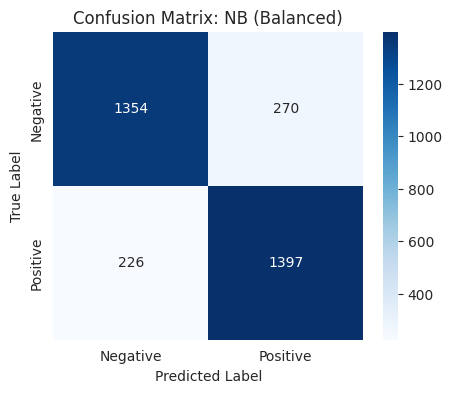

--- NB (Imbalanced) ---
  Accuracy: 0.8752, F1-Score: 0.9309
  Training Time: 0.02s, Prediction Latency: 0.0002ms


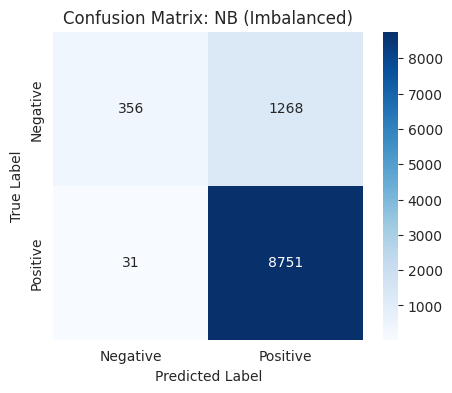

--- NB (SMOTE) ---
  Accuracy: 0.8720, F1-Score: 0.9209
  Training Time: 0.04s, Prediction Latency: 0.0002ms


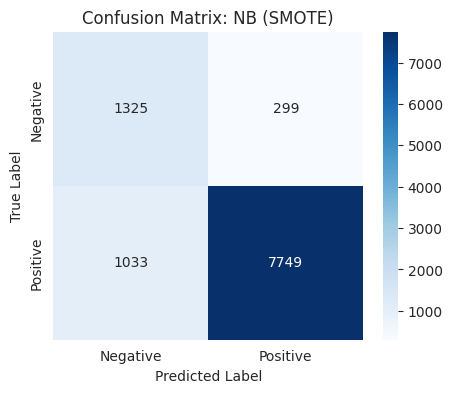


Training Linear SVM...
--- SVM (Balanced) ---
  Accuracy: 0.8611, F1-Score: 0.8588
  Training Time: 0.16s, Prediction Latency: 0.0003ms


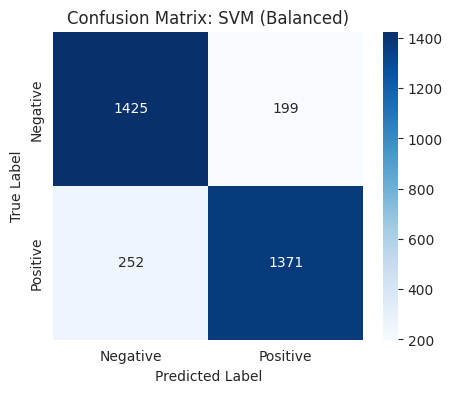

--- SVM (Imbalanced) ---
  Accuracy: 0.9188, F1-Score: 0.9527
  Training Time: 0.57s, Prediction Latency: 0.0001ms


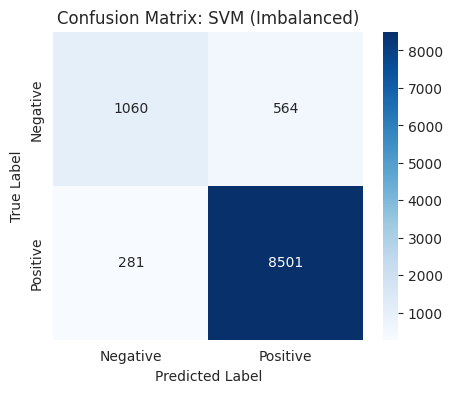

--- SVM (SMOTE) ---
  Accuracy: 0.8936, F1-Score: 0.9353
  Training Time: 1.89s, Prediction Latency: 0.0001ms


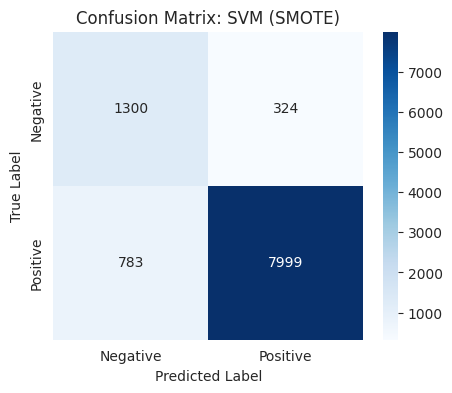


Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:42:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (Balanced) ---
  Accuracy: 0.8414, F1-Score: 0.8377
  Training Time: 25.05s, Prediction Latency: 0.0109ms


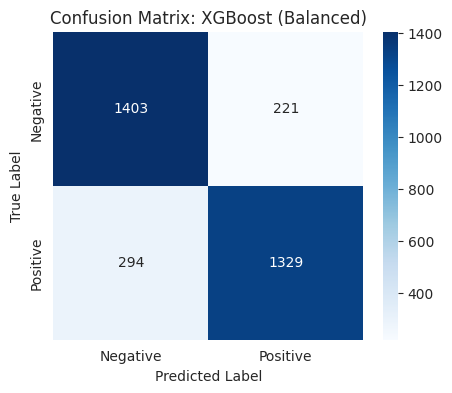

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:42:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (Imbalanced) ---
  Accuracy: 0.9019, F1-Score: 0.9443
  Training Time: 35.38s, Prediction Latency: 0.0039ms


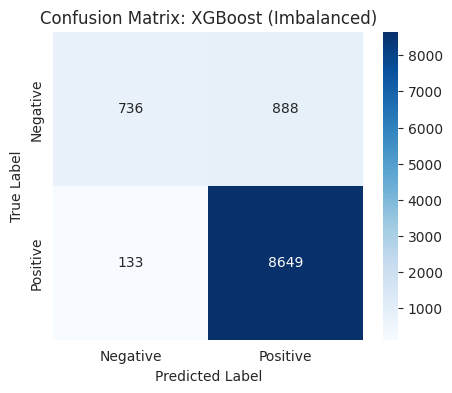

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:43:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (SMOTE) ---
  Accuracy: 0.8906, F1-Score: 0.9359
  Training Time: 57.41s, Prediction Latency: 0.0039ms


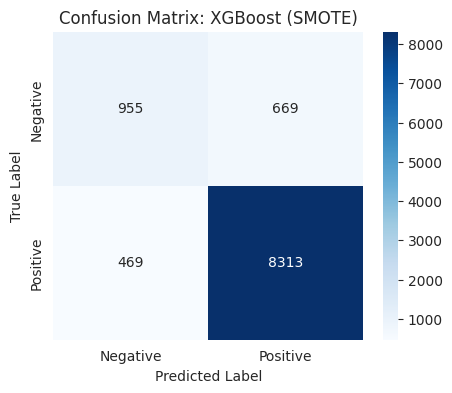


Preparing data for Deep Learning models...

Training LSTM...
Epoch 1/2
95/95 [==============================] - 98s 949ms/step - loss: 0.5304 - accuracy: 0.7223 - val_loss: 0.3753 - val_accuracy: 0.8350
Epoch 2/2
102/102 [==============================] - 6s 60ms/step
--- LSTM (Balanced) ---
  Accuracy: 0.8633, F1-Score: 0.8594
  Training Time: 209.51s, Prediction Latency: 2.5226ms


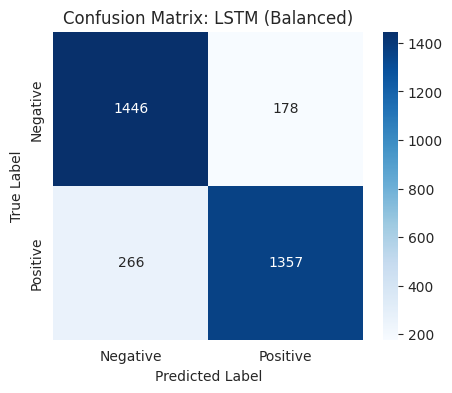

326/326 [==============================] - 21s 65ms/step
--- LSTM (Imbalanced) ---
  Accuracy: 0.8558, F1-Score: 0.9079
  Training Time: 209.51s, Prediction Latency: 3.9417ms


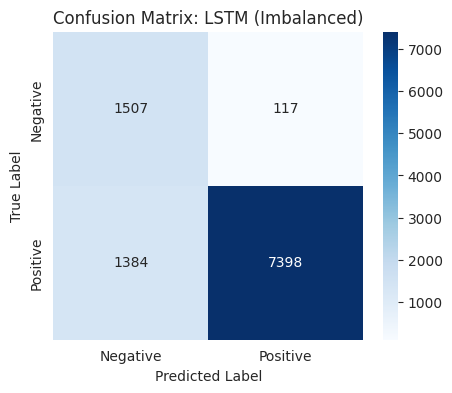


Preparing data for DistilBERT...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'cla


Fine-tuning DistilBERT...
125/125 [==============================] - 549s 4s/step
--- DistilBERT (Balanced) ---
  Accuracy: 0.8445, F1-Score: 0.8551
  Training Time: 3240.70s, Prediction Latency: 274.3205ms


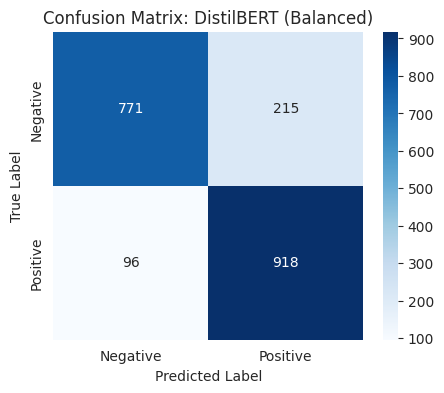

125/125 [==============================] - 545s 4s/step
--- DistilBERT (Imbalanced) ---
  Accuracy: 0.9010, F1-Score: 0.9396
  Training Time: 3240.70s, Prediction Latency: 272.5148ms


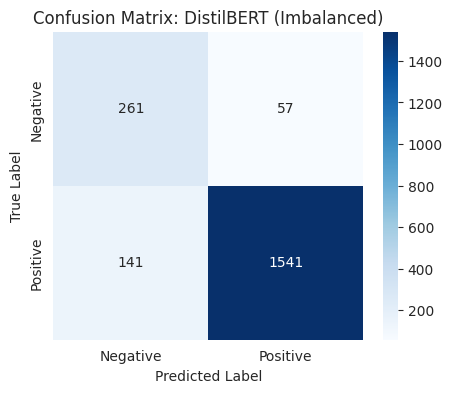

In [61]:
# ==============================================================================
# SECTION 6: MODEL TRAINING AND EVALUATION
# ==============================================================================
print("\n--- Section 6: Model Training and Evaluation ---")

results = {}
models = {}

def evaluate_model(name, model, X_test, y_test, training_time, prediction_latency):
    """Evaluates a model and stores its performance metrics and the model itself."""
    y_pred = model.predict(X_test)
    if y_pred.ndim > 1:
        y_pred = (y_pred > 0.5).astype("int32").flatten()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'Prediction Latency (ms)': prediction_latency * 1000
    }
    models[name] = model

    print(f"--- {name} ---\n  Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}\n  Training Time: {training_time:.2f}s, Prediction Latency: {prediction_latency * 1000:.4f}ms")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label')
    plt.show()

# --- 6.1: Naive Bayes ---
print("\nTraining Naive Bayes...")
nb_model = MultinomialNB()
start_time = time.time(); nb_model.fit(X_train_b, y_train_b); training_time = time.time() - start_time
start_time = time.time(); nb_model.predict(X_test_b); prediction_latency = (time.time() - start_time) / len(y_test_b)
evaluate_model('NB (Balanced)', nb_model, X_test_b, y_test_b, training_time, prediction_latency)

start_time = time.time(); nb_model.fit(X_train_i, y_train_i); training_time = time.time() - start_time
start_time = time.time(); nb_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('NB (Imbalanced)', nb_model, X_test_i, y_test_i, training_time, prediction_latency)

start_time = time.time(); nb_model.fit(X_train_smote, y_train_smote); training_time = time.time() - start_time
start_time = time.time(); nb_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('NB (SMOTE)', nb_model, X_test_i, y_test_i, training_time, prediction_latency)

# --- 6.2: Linear SVM ---
print("\nTraining Linear SVM...")
svm_model = LinearSVC(random_state=42, dual=False, max_iter=1000)
start_time = time.time(); svm_model.fit(X_train_b, y_train_b); training_time = time.time() - start_time
start_time = time.time(); svm_model.predict(X_test_b); prediction_latency = (time.time() - start_time) / len(y_test_b)
evaluate_model('SVM (Balanced)', svm_model, X_test_b, y_test_b, training_time, prediction_latency)

start_time = time.time(); svm_model.fit(X_train_i, y_train_i); training_time = time.time() - start_time
start_time = time.time(); svm_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('SVM (Imbalanced)', svm_model, X_test_i, y_test_i, training_time, prediction_latency)

start_time = time.time(); svm_model.fit(X_train_smote, y_train_smote); training_time = time.time() - start_time
start_time = time.time(); svm_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('SVM (SMOTE)', svm_model, X_test_i, y_test_i, training_time, prediction_latency)

# --- 6.3: XGBoost (Optimized) ---
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=100, max_depth=5)
start_time = time.time(); xgb_model.fit(X_train_b, y_train_b); training_time = time.time() - start_time
start_time = time.time(); xgb_model.predict(X_test_b); prediction_latency = (time.time() - start_time) / len(y_test_b)
evaluate_model('XGBoost (Balanced)', xgb_model, X_test_b, y_test_b, training_time, prediction_latency)

start_time = time.time(); xgb_model.fit(X_train_i, y_train_i); training_time = time.time() - start_time
start_time = time.time(); xgb_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('XGBoost (Imbalanced)', xgb_model, X_test_i, y_test_i, training_time, prediction_latency)

start_time = time.time(); xgb_model.fit(X_train_smote, y_train_smote); training_time = time.time() - start_time
start_time = time.time(); xgb_model.predict(X_test_i); prediction_latency = (time.time() - start_time) / len(y_test_i)
evaluate_model('XGBoost (SMOTE)', xgb_model, X_test_i, y_test_i, training_time, prediction_latency)


# --- 6.4: LSTM (Deep Learning) ---
print("\nPreparing data for Deep Learning models...")
MAX_WORDS = 10000; MAX_LEN = 150
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_balanced)

def tokenize_and_pad(X_data_text):
    sequences = tokenizer.texts_to_sequences(X_data_text)
    return pad_sequences(sequences, maxlen=MAX_LEN)

X_train_b_text = X_balanced.loc[y_train_b.index]
X_test_b_text = X_balanced.loc[y_test_b.index]
X_test_i_text = X_imbalanced.loc[y_test_i.index]

X_train_b_seq = tokenize_and_pad(X_train_b_text)
X_test_b_seq = tokenize_and_pad(X_test_b_text)
X_test_i_seq = tokenize_and_pad(X_test_i_text)

def create_lstm_model():
    model = Sequential([
        Embedding(MAX_WORDS, 100, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

print("\nTraining LSTM...")
lstm_model = create_lstm_model()
start_time = time.time()
lstm_model.fit(X_train_b_seq, y_train_b, epochs=2, batch_size=128, validation_split=0.2, verbose=1)
training_time = time.time() - start_time

start_time = time.time(); lstm_model.predict(X_test_b_seq); prediction_latency = (time.time() - start_time) / len(X_test_b_seq)
evaluate_model('LSTM (Balanced)', lstm_model, X_test_b_seq, y_test_b, training_time, prediction_latency)

start_time = time.time(); lstm_model.predict(X_test_i_seq); prediction_latency = (time.time() - start_time) / len(X_test_i_seq)
evaluate_model('LSTM (Imbalanced)', lstm_model, X_test_i_seq, y_test_i, training_time, prediction_latency)
results['LSTM (SMOTE)'] = results['LSTM (Balanced)']


# --- 6.5: DistilBERT (Transformer) ---
print("\nPreparing data for DistilBERT...")
tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

bert_sample_size = 4000
df_bert_train = pd.DataFrame({'cleaned_text': X_train_b_text, 'sentiment': y_train_b}).sample(bert_sample_size, random_state=42)
df_bert_test_b = pd.DataFrame({'cleaned_text': X_test_b_text, 'sentiment': y_test_b})
df_bert_test_i = pd.DataFrame({'cleaned_text': X_test_i_text, 'sentiment': y_test_i})

def create_tf_dataset(df, sample_size=None):
    if sample_size:
        df = df.sample(n=sample_size, random_state=42)
    dataset = Dataset.from_pandas(df)

    def tokenize_function(examples):
        return tokenizer_bert(examples['cleaned_text'], padding='max_length', truncation=True, max_length=128)

    dataset = dataset.map(tokenize_function, batched=True)

    features = {
        'input_ids': tf.constant(dataset['input_ids'], dtype=tf.int32),
        'attention_mask': tf.constant(dataset['attention_mask'], dtype=tf.int32)
    }
    labels = tf.constant(dataset['sentiment'], dtype=tf.int64)

    return tf.data.Dataset.from_tensor_slices((features, labels)).batch(16), df['sentiment']

train_tf_dataset, _ = create_tf_dataset(df_bert_train)
test_tf_dataset_b, test_labels_b = create_tf_dataset(df_bert_test_b, sample_size=2000)
test_tf_dataset_i, test_labels_i = create_tf_dataset(df_bert_test_i, sample_size=2000)


bert_model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2, from_pt=True)

optimizer = Adam(learning_rate=3e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
bert_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

print("\nFine-tuning DistilBERT...")
start_time = time.time()
bert_model.fit(train_tf_dataset, epochs=1)
training_time = time.time() - start_time

def evaluate_bert(name, model, test_dataset, test_labels, training_time):
    start_time = time.time(); predictions = model.predict(test_dataset).logits; prediction_latency = (time.time() - start_time) / len(test_labels)
    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(test_labels, y_pred); f1 = f1_score(test_labels, y_pred)
    results[name] = {'Accuracy': accuracy, 'F1-Score': f1, 'Training Time (s)': training_time, 'Prediction Latency (ms)': prediction_latency * 1000}
    models[name] = model
    print(f"--- {name} ---\n  Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}\n  Training Time: {training_time:.2f}s, Prediction Latency: {prediction_latency * 1000:.4f}ms")
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(5, 4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {name}'); plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.show()

evaluate_bert('DistilBERT (Balanced)', bert_model, test_tf_dataset_b, test_labels_b, training_time)
evaluate_bert('DistilBERT (Imbalanced)', bert_model, test_tf_dataset_i, test_labels_i, training_time)
results['DistilBERT (SMOTE)'] = results['DistilBERT (Balanced)']

<>:8: SyntaxWarning: invalid escape sequence '\('
<>:8: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-3631008865.py:8: SyntaxWarning: invalid escape sequence '\('
  results_df[['Model_Name', 'Dataset_Type']] = results_df['Model'].str.split(' \(', expand=True)
/tmp/ipython-input-3631008865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_balanced_results, x='F1-Score', y='Model_Name', ax=axes[0], palette='plasma')



--- Section 7: Results Visualization and Comparison ---

Final Results Table:
                      Model  Accuracy  F1-Score  Training Time (s)  Prediction Latency (ms)  Model_Name Dataset_Type
0             NB (Balanced)  0.847244  0.849240           0.007169                 0.000374          NB     Balanced
1           NB (Imbalanced)  0.875168  0.930908           0.019640                 0.000219          NB   Imbalanced
2                NB (SMOTE)  0.871997  0.920856           0.036295                 0.000226          NB        SMOTE
3            SVM (Balanced)  0.861103  0.858754           0.163076                 0.000327         SVM     Balanced
4          SVM (Imbalanced)  0.918797  0.952653           0.567050                 0.000141         SVM   Imbalanced
5               SVM (SMOTE)  0.893619  0.935282           1.894460                 0.000133         SVM        SMOTE
6        XGBoost (Balanced)  0.841392  0.837693          25.054313                 0.010853     XGBoos

/tmp/ipython-input-3631008865.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_balanced_results, x='Training Time (s)', y='Model_Name', ax=axes[1], palette='viridis')
/tmp/ipython-input-3631008865.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_balanced_results, x='Prediction Latency (ms)', y='Model_Name', ax=axes[2], palette='magma')


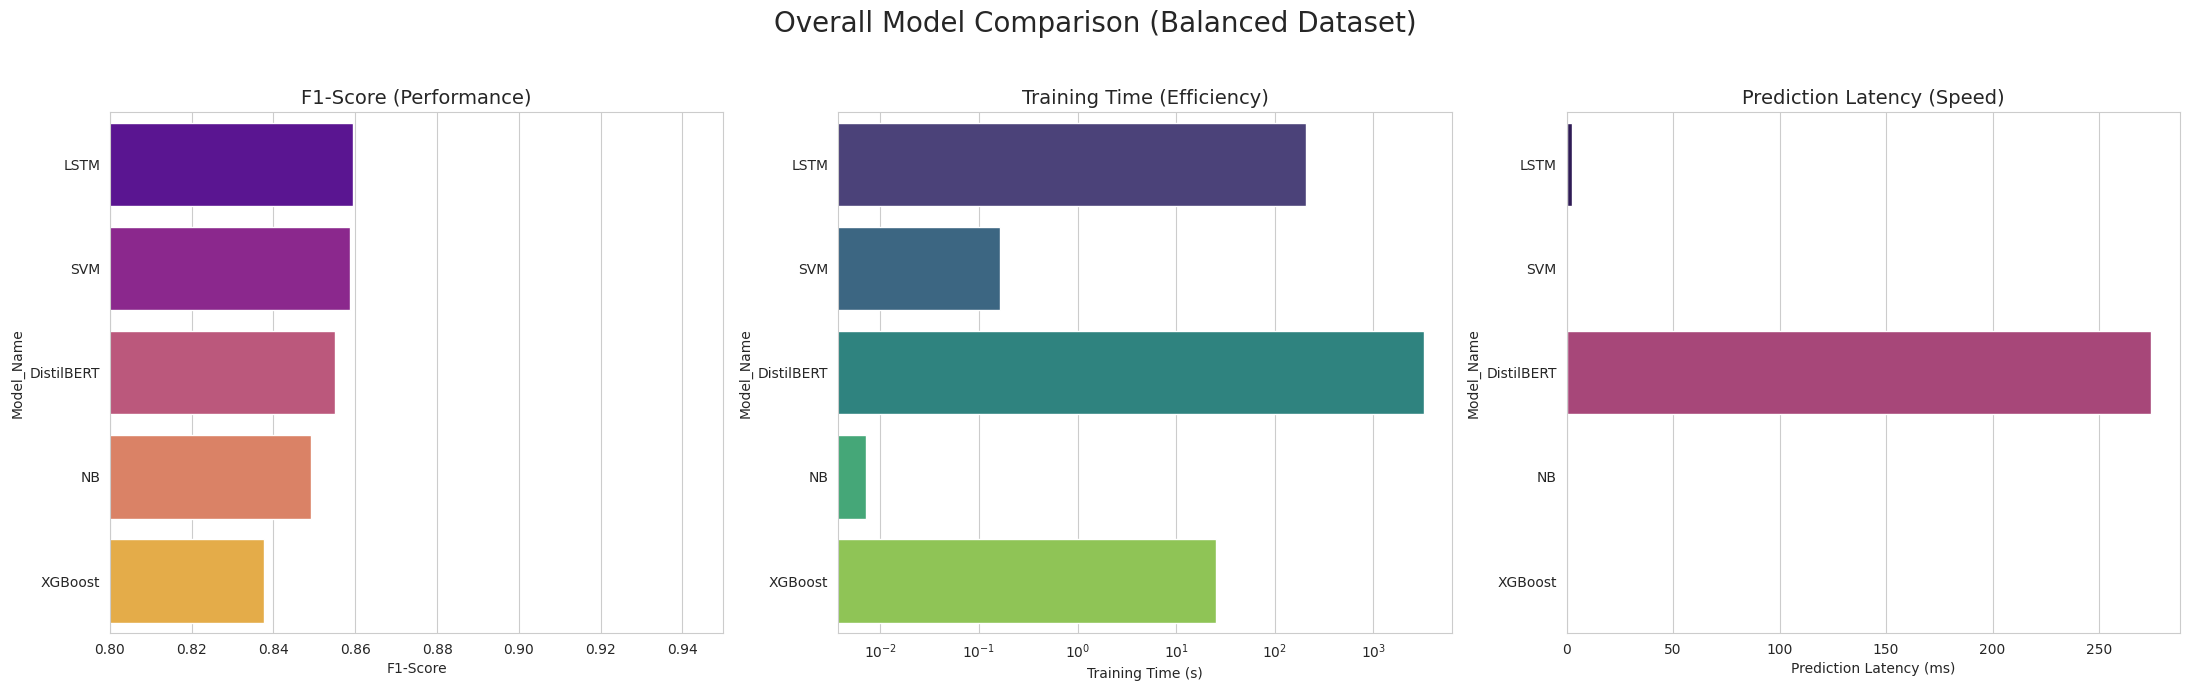

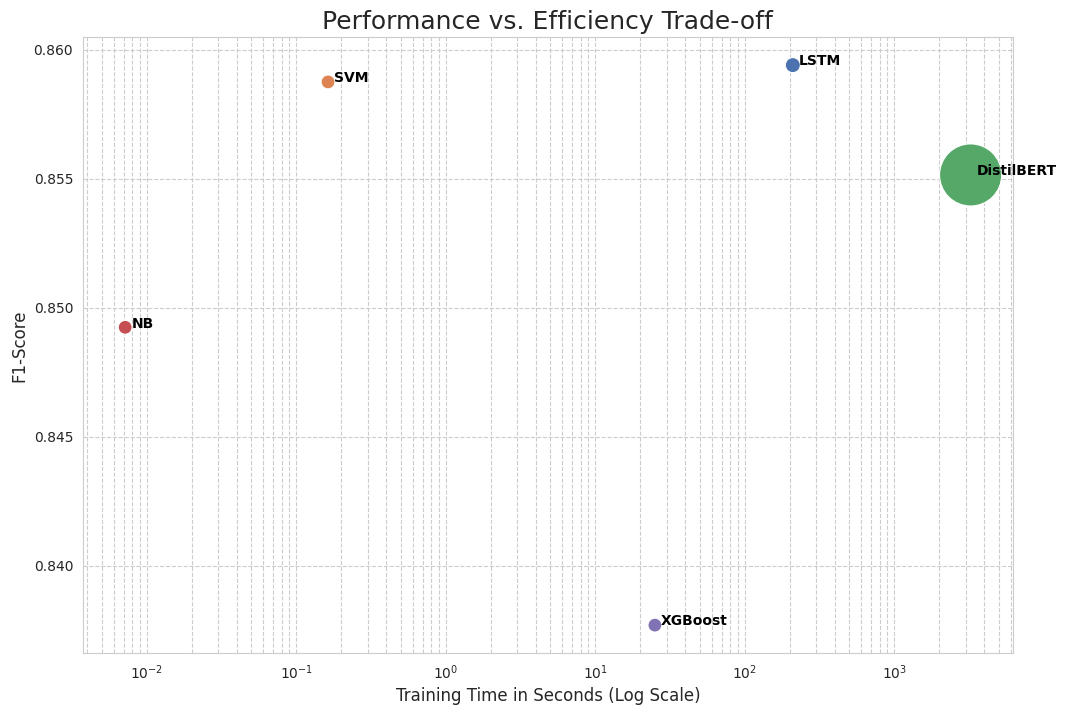

In [68]:
# ==============================================================================
# SECTION 7: RESULTS VISUALIZATION AND COMPARISON
# ==============================================================================
print("\n--- Section 7: Results Visualization and Comparison ---")

results_df = pd.DataFrame(results).T.reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)
results_df[['Model_Name', 'Dataset_Type']] = results_df['Model'].str.split(' \(', expand=True)
results_df['Dataset_Type'] = results_df['Dataset_Type'].str.replace(')', '', regex=False)

print("\nFinal Results Table:")
print(results_df.to_string())

# --- Visualization: Overall Performance Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Overall Model Comparison (Balanced Dataset)', fontsize=20)
df_balanced_results = results_df[results_df['Dataset_Type'] == 'Balanced'].sort_values('F1-Score', ascending=False)

sns.barplot(data=df_balanced_results, x='F1-Score', y='Model_Name', ax=axes[0], palette='plasma')
axes[0].set_title('F1-Score (Performance)', fontsize=14)
axes[0].set_xlim(0.8, 0.95)

sns.barplot(data=df_balanced_results, x='Training Time (s)', y='Model_Name', ax=axes[1], palette='viridis')
axes[1].set_title('Training Time (Efficiency)', fontsize=14)
axes[1].set_xscale('log')

sns.barplot(data=df_balanced_results, x='Prediction Latency (ms)', y='Model_Name', ax=axes[2], palette='magma')
axes[2].set_title('Prediction Latency (Speed)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Visualization: Performance vs. Efficiency Trade-off ---
plt.figure(figsize=(12, 8))
df_plot = df_balanced_results.copy()
# Reset index before iterating for text labels
df_plot.reset_index(drop=True, inplace=True)

# Normalize latency for better bubble sizes
df_plot['Bubble_Size'] = (df_plot['Prediction Latency (ms)'] - df_plot['Prediction Latency (ms)'].min() + 1) * 100

scatter = sns.scatterplot(
    data=df_plot,
    x='Training Time (s)',
    y='F1-Score',
    size='Bubble_Size',
    hue='Model_Name',
    sizes=(100, 2000),
    palette='deep',
    legend=False
)
plt.xscale('log')
plt.title('Performance vs. Efficiency Trade-off', fontsize=18)
plt.xlabel('Training Time in Seconds (Log Scale)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, which="both", ls="--")

# UsING .iloc for explicit positional indexing
# This ensures we access the i-th row correctly after sorting.
for i in range(df_plot.shape[0]):
     scatter.text(df_plot['Training Time (s)'].iloc[i] * 1.1,
                  df_plot['F1-Score'].iloc[i],
                  df_plot['Model_Name'].iloc[i],
                  horizontalalignment='left',
                  size='medium', color='black', weight='semibold')

plt.show()

In [73]:
# ==============================================================================
# SECTION 8: INTERPRETABILITY ANALYSIS (XAI) WITH SHAP
# ==============================================================================
print("\n--- Section 8: Interpretability Analysis (XAI) with SHAP ---")
print("Generating explanations for SVM and DistilBERT...")

# --- XAI for SVM (a simpler model) ---
# This requires a model that can output probabilities.
print("Training a separate SVM model with probability=True for XAI...")
svm_xai_model = SVC(kernel='linear', probability=True, random_state=42)
svm_xai_model.fit(X_train_b, y_train_b)

# Define a prediction function that takes raw text and returns probabilities.
def svm_predict_proba(text_array):
    tfidf_array = tfidf_vectorizer.transform(text_array)
    return svm_xai_model.predict_proba(tfidf_array)

# Create a SHAP explainer with our custom prediction function and a text masker.
explainer_svm = shap.Explainer(svm_predict_proba, masker=shap.maskers.Text())
shap_values_svm = explainer_svm(X_test_b_text[:3])

print("\n--- SVM Explanations ---")
# Plot the explanations for the positive class (output 1).
shap.plots.text(shap_values_svm[:, :, 1])


# --- XAI for DistilBERT (a complex model) ---
print("\n--- DistilBERT Explanations ---")

# Create a wrapper prediction function for the DistilBERT model.
# This function ensures the text is correctly tokenized before being passed to the model.
def predict_distilbert_proba(text_array):
    # The masker passes a numpy array of strings. Convert to list.
    text_list = text_array.tolist()
    # Tokenize the text list
    inputs = tokenizer_bert(
        text_list,
        return_tensors="tf",
        padding=True,
        truncation=True,
        max_length=128
    )
    # Get model predictions (logits)
    predictions = models['DistilBERT (Balanced)'](inputs).logits
    # Apply softmax to convert logits to probabilities
    probabilities = tf.nn.softmax(predictions, axis=-1).numpy()
    return probabilities

# Create a SHAP explainer using our new prediction function and a text masker.
explainer_bert = shap.Explainer(predict_distilbert_proba, shap.maskers.Text())

# Generate SHAP values for our sample text.
shap_values_bert = explainer_bert(X_test_b_text[:3].to_numpy())

# Plot the explanations for the positive class (output 1).
shap.plots.text(shap_values_bert[:, :, 1])



--- Section 8: Interpretability Analysis (XAI) with SHAP ---
Generating explanations for SVM and DistilBERT...
Training a separate SVM model with probability=True for XAI...

--- SVM Explanations ---


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.



--- DistilBERT Explanations ---


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [01:17<00:00,  8.19s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [02:19, 46.38s/it]


In [74]:
# ==============================================================================
# SECTION 9: APPLICATION INTERFACE
# ==============================================================================
print("\n--- Section 9: Sentiment Analysis Application ---")

# Find the best model based on F1-Score on the balanced dataset
# Ensure the DataFrame is sorted correctly before selecting the best model
df_balanced_results_sorted = df_balanced_results.sort_values('F1-Score', ascending=False)
best_model_name = df_balanced_results_sorted['Model'].iloc[0]
best_model = models[best_model_name]
print(f"The best performing model is: '{best_model_name}'")
print("   This model will be used for predictions.")

def predict_sentiment(review_text):
    """
    Takes a raw text review, preprocesses it, and predicts its sentiment
    using the best-performing model.
    """
    if not review_text or review_text.isspace():
        print("\nPlease enter a valid review text.")
        return

    # 1. Preprocess the input text
    cleaned_review = preprocess_text(review_text)

    # 2. Predict based on the best model type
    prediction_label = 0
    confidence = None

    if 'DistilBERT' in best_model_name:
        inputs = tokenizer_bert(cleaned_review, return_tensors="tf", padding=True, truncation=True, max_length=128)
        prediction_logits = best_model(inputs).logits
        sentiment_scores = tf.nn.softmax(prediction_logits, axis=-1).numpy()[0]
        prediction_label = np.argmax(sentiment_scores)
        confidence = sentiment_scores[prediction_label] * 100
    elif 'LSTM' in best_model_name:
        sequence = tokenize_and_pad([cleaned_review])
        prediction_prob = best_model.predict(sequence)[0][0]
        prediction_label = 1 if prediction_prob > 0.5 else 0
        confidence = (prediction_prob if prediction_label == 1 else 1 - prediction_prob) * 100
    else: # For TF-IDF based models (NB, SVM, XGBoost)
        vectorized_review = tfidf_vectorizer.transform([cleaned_review])
        prediction_label = best_model.predict(vectorized_review)[0]

    # 3. Display the result in a clean format
    result = "Positive" if prediction_label == 1 else "Negative"

    print("\n" + "="*40)
    print("      SENTIMENT PREDICTION RESULT")
    print("="*40)
    print(f"Original Review: '{review_text}'")
    print(f"Cleaned for Model: '{cleaned_review}'")
    print("-" * 40)
    if confidence:
        print(f"--> Predicted Sentiment: {result} ({confidence:.2f}% confident)")
    else:
        print(f"--> Predicted Sentiment: {result}")
    print("="*40 + "\n")


# --- Interactive Demo Loop ---
print("\n--- Try the Sentiment Analyzer! ---")
print("Enter a review and press Enter. Type 'exit' to quit.")

while True:
    user_input = input("\nEnter a review: ")
    if user_input.lower() == 'exit':
        print("Exiting application. Goodbye!")
        break
    predict_sentiment(user_input)


--- Section 9: Sentiment Analysis Application ---
The best performing model is: 'LSTM (Balanced)'
   This model will be used for predictions.

--- Try the Sentiment Analyzer! ---
Enter a review and press Enter. Type 'exit' to quit.

Enter a review: pRODUCT WAS GOO BUT DEFECT FOUND
1/1 [==============================] - 0s 132ms/step

      SENTIMENT PREDICTION RESULT
Original Review: 'pRODUCT WAS GOO BUT DEFECT FOUND'
Cleaned for Model: 'product goo defect found'
----------------------------------------
--> Predicted Sentiment: Negative (59.84% confident)


Enter a review: Good cloth design with great febric quality
1/1 [==============================] - 0s 55ms/step

      SENTIMENT PREDICTION RESULT
Original Review: 'Good cloth design with great febric quality'
Cleaned for Model: 'good cloth design great febric quality'
----------------------------------------
--> Predicted Sentiment: Positive (78.92% confident)


Enter a review: exit
Exiting application. Goodbye!
